<a href="https://colab.research.google.com/github/mayashah100/MEI-Data-Science-Project/blob/main/MEI_DataScienceCourse_Lesson2_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MEI Introduction to Data Science: Lesson 2 - Activity 2

# Introduction

This activity show you how to clean and prepare data by
* removing unwanted rows
* replacing categorical values that have been stored as numbers
* filtering a dataset

The activity uses the data from the AQA large data set which gives information about cars. For more information about the data see the short video at: https://mei.org.uk/introduction-to-data-science/large-data-sets/

## Problem
* ***Are petrol or diesel cars heavier and which have higher $CO_2$ emissions?***
* ***Are there differences for cars of different makes?***

To answer this question you could find statistics and create charts of the masses and emissions of petrol and diesel cars in the dataset.

## Importing libraries and data

> Run the code boxes below to import the libraries and the data

In [ ]:
# import pandas for data analysis
import pandas as pd

# import seaborn for visualisations
import seaborn as sns

In [ ]:
# import the data to your Google Drive - data is at https://drive.google.com/file/d/1N632vbSCqG6i1DLYYIjFB6fxAFciacWv/view?usp=sharing
!gdown '1N632vbSCqG6i1DLYYIjFB6fxAFciacWv'

# import the csv file to a data set called cars_data
cars_data = pd.read_csv('/content/AQA-large-data-set.csv')

# display the data
cars_data

Downloading...
From: https://drive.google.com/uc?id=1N632vbSCqG6i1DLYYIjFB6fxAFciacWv
To: /content/AQA-large-data-set.csv
100% 299k/299k [00:00<00:00, 99.0MB/s]


,ReferenceNumber,Make,PropulsionTypeId,BodyTypeId,GovRegion,KeeperTitleId,EngineSize,YearRegistered,Mass,CO2,CO,NOX,part,hc,Random number
0,440,VAUXHALL,1,96,London,1,1598,2002,1970,190,0.219,0.026,NaN,0.037,0.430217
1,1465,VAUXHALL,1,14,South West,5,1398,2016,1163,118,0.463,0.010,NaN,0.031,0.797111
2,3434,VOLKSWAGEN,1,14,South West,2,1395,2016,1316,113,0.242,0.033,NaN,0.048,0.348442
3,1801,VAUXHALL,1,14,South West,4,1598,2016,1355,159,0.809,0.012,NaN,0.051,0.968447
4,2330,BMW,2,13,South West,5,1995,2016,1445,114,0.180,0.023,NaN,NaN,0.178227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3822,2920,FORD,2,14,North West,5,1997,2016,1681,122,0.145,0.059,0.001,NaN,0.946550
3823,1800,FORD,2,96,London,2,1997,2016,1833,134,0.305,0.054,NaN,NaN,0.538774
3824,3498,FORD,1,14,South West,1,999,2016,1333,108,0.447,0.030,0.002,0.076,0.736612
3825,2802,VAUXHALL,1,14,North West,5,1364,2016,1409,149,0.699,0.008,NaN,0.044,0.748846


Before processing and exploring the data you should always check the data types.

> Use the `info()` command you learnt in lesson 1 to explore the data types

*Reminder: the format for this command in lesson 2 was* `weather_data.info()`

In [ ]:
# explore the data types
cars_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3827 entries, 0 to 3826
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ReferenceNumber   3827 non-null   int64  
 1   Make              3827 non-null   object 
 2   PropulsionTypeId  3827 non-null   int64  
 3   BodyTypeId        3827 non-null   int64  
 4   GovRegion         3827 non-null   object 
 5   KeeperTitleId     3827 non-null   int64  
 6   EngineSize        3827 non-null   int64  
 7   YearRegistered    3827 non-null   int64  
 8   Mass              3827 non-null   int64  
 9   CO2               3827 non-null   int64  
 10  CO                3814 non-null   float64
 11  NOX               3753 non-null   float64
 12  part              722 non-null    float64
 13  hc                2405 non-null   float64
 14  Random number     3827 non-null   float64
dtypes: float64(5), int64(8), object(2)
memory usage: 448.6+ KB


# Pre-processing the data 1
## Checking the data
With any dataset you should perform some checks to ensure that the data imported for a feature have suitable values. The code below uses the `describe()` command to get a summary of the data in the `Mass` feature.

> Run the code below.

In [ ]:
# display the statistics for Mass
cars_data['Mass'].describe()

,Mass
count,3827.000000
mean,1369.793049
std,329.117091
min,0.000000
25%,1167.000000
50%,1393.000000
75%,1570.000000
max,2450.000000


In this activity you are also exploring the $CO_2$ emissions of the cars.

> Copy the code into the box below to explore the values of $CO_2$ emissions

In [ ]:
# display the statistics for CO2
cars_data['CO2'].describe()

,CO2
count,3827.000000
mean,137.628691
std,36.555543
min,0.000000
25%,114.000000
50%,129.000000
75%,158.000000
max,356.000000


## Creating a copy with rows removed

The value of 0 is not a suitable value for the mass of a car.

The are also some values of $CO_2$ emissions that are 0. In this activity you are comparing petrol and diesel cars. These are unlikely to have $CO_2$ emissions of 0.

The code below creates a new copy of the data set by selecting on those rows where the mass is greater than zero **and** the $CO_2$ emissions are greater than zero.

> Run the code below

In [ ]:
# a new copy of the dataset called cars_data2 is created containing only those values from the original cars_data dataset where the value of cars_data['Mass']>0 and cars_data['CO2']>0
cars_data2=cars_data[(cars_data['Mass'] >0) & (cars_data['CO2'] >0)].copy()

# check the data set has been created correctly
cars_data2

,ReferenceNumber,Make,PropulsionTypeId,BodyTypeId,GovRegion,KeeperTitleId,EngineSize,YearRegistered,Mass,CO2,CO,NOX,part,hc,Random number
0,440,VAUXHALL,1,96,London,1,1598,2002,1970,190,0.219,0.026,NaN,0.037,0.430217
1,1465,VAUXHALL,1,14,South West,5,1398,2016,1163,118,0.463,0.010,NaN,0.031,0.797111
2,3434,VOLKSWAGEN,1,14,South West,2,1395,2016,1316,113,0.242,0.033,NaN,0.048,0.348442
3,1801,VAUXHALL,1,14,South West,4,1598,2016,1355,159,0.809,0.012,NaN,0.051,0.968447
4,2330,BMW,2,13,South West,5,1995,2016,1445,114,0.180,0.023,NaN,NaN,0.178227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3822,2920,FORD,2,14,North West,5,1997,2016,1681,122,0.145,0.059,0.001,NaN,0.946550
3823,1800,FORD,2,96,London,2,1997,2016,1833,134,0.305,0.054,NaN,NaN,0.538774
3824,3498,FORD,1,14,South West,1,999,2016,1333,108,0.447,0.030,0.002,0.076,0.736612
3825,2802,VAUXHALL,1,14,North West,5,1364,2016,1409,149,0.699,0.008,NaN,0.044,0.748846


You can check that all the values are > 0 by using `.describe()` on both of these columns.

* Copy and change the code into the boxes below to calculate the statistics for the `Mass` and `CO2` features for the `cars_data2` dataset

In [ ]:
# display the statistics for Mass
cars_data2['Mass'].describe()

,Mass
count,3733.000000
mean,1403.642111
std,252.245350
min,925.000000
25%,1175.000000
50%,1395.000000
75%,1575.000000
max,2450.000000


In [ ]:
# display the statistics for CO2
cars_data2['CO2'].describe()

,CO2
count,3733.000000
mean,136.872489
std,36.005557
min,13.000000
25%,114.000000
50%,128.000000
75%,158.000000
max,356.000000


## Checkpoint 1
> * Why might values of 0 have been recorded for the masses of some of the cars in the original data?
> * Why is a value of 0 for `CO2` unrealistic for petrol or diesel cars? Are there any cars in the data set that could genuinely have a `CO2` value of 0?
> * Are the statistics given by `cars_data2['Mass'].describe()` suitable for the masses of cars? Give some supporting evidence for your answer.

## Creating a text feature for a category stored as numbers
The `PropulsionTypeId` feature is categorical data but it has been stored as numerical data using a code which references the engine type. Many of the commands in the pandas and seaborn libraries work better with categorical data when it as stored as text, i.e. the `object` data type.

The code below replaces these values with the actual descriptions.	<br>
1:	Petrol<br>
2:	Diesel<br>
3:	Electric<br>
7:	Gas/Petrol<br>
8:	Electric/Petrol
> Run the code below to create a text feature for propulsion type.

In [ ]:
# a new feature is created - the replace dictionary uses a colon to indicate what is to be replaced and commas to separate the items
cars_data2['PropulsionType'] = cars_data2['PropulsionTypeId'].replace({1: 'Petrol',
                                                                       2: 'Diesel',
                                                                       3: 'Electric',
                                                                       7: 'Gas/Petrol',
                                                                       8: 'Electric/Petrol'})

# display the data to check
cars_data2

,ReferenceNumber,Make,PropulsionTypeId,BodyTypeId,GovRegion,KeeperTitleId,EngineSize,YearRegistered,Mass,CO2,CO,NOX,part,hc,Random number,PropulsionType
0,440,VAUXHALL,1,96,London,1,1598,2002,1970,190,0.219,0.026,NaN,0.037,0.430217,Petrol
1,1465,VAUXHALL,1,14,South West,5,1398,2016,1163,118,0.463,0.010,NaN,0.031,0.797111,Petrol
2,3434,VOLKSWAGEN,1,14,South West,2,1395,2016,1316,113,0.242,0.033,NaN,0.048,0.348442,Petrol
3,1801,VAUXHALL,1,14,South West,4,1598,2016,1355,159,0.809,0.012,NaN,0.051,0.968447,Petrol
4,2330,BMW,2,13,South West,5,1995,2016,1445,114,0.180,0.023,NaN,NaN,0.178227,Diesel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3822,2920,FORD,2,14,North West,5,1997,2016,1681,122,0.145,0.059,0.001,NaN,0.946550,Diesel
3823,1800,FORD,2,96,London,2,1997,2016,1833,134,0.305,0.054,NaN,NaN,0.538774,Diesel
3824,3498,FORD,1,14,South West,1,999,2016,1333,108,0.447,0.030,0.002,0.076,0.736612,Petrol
3825,2802,VAUXHALL,1,14,North West,5,1364,2016,1409,149,0.699,0.008,NaN,0.044,0.748846,Petrol


# Exploring the data 1
## Comparing the mass and emissions of the different propulsion types
The code in the boxes below will calculate the statistics and create box plots for the masses grouped by propulsion type.

> Run the code in the boxes below.

In [ ]:
# calculate the statistics for Mass grouped by PropulsionType
cars_data2.groupby('PropulsionType')['Mass'].describe()

,count,mean,std,min,25%,50%,75%,max
PropulsionType,,,,,,,,
Diesel,1365.0,1555.499634,218.744627,1056.0,1398.0,1533.0,1681.0,2450.0
Electric/Petrol,118.0,1600.567797,244.484893,1176.0,1470.0,1605.0,1735.0,2305.0
Gas/Petrol,1.0,1710.000000,NaN,1710.0,1710.0,1710.0,1710.0,1710.0
Petrol,2249.0,1301.005780,216.490640,925.0,1163.0,1260.0,1430.0,2350.0


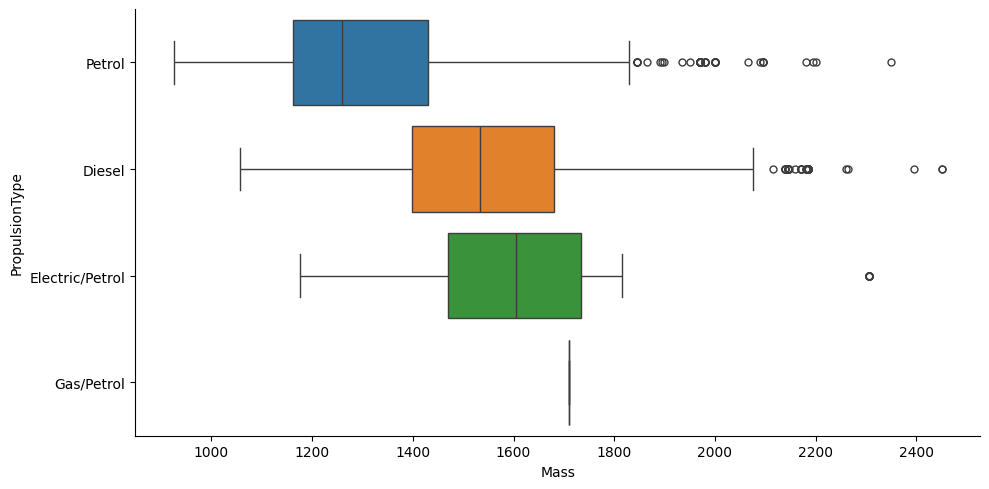

In [ ]:
# create box plots for Mass grouped by PropulsionType
sns.catplot(data=cars_data2, kind='box', x='Mass', y='PropulsionType', hue='PropulsionType', aspect=2);

> Copy the code into the following box and change it so that it finds the statistics and creates the box plots for $CO_2$ emissions grouped by PropulsionType.

In [ ]:
# calculate the statistics for CO2 grouped by PropulsionType
cars_data2.groupby('PropulsionType')['CO2'].describe()

,count,mean,std,min,25%,50%,75%,max
PropulsionType,,,,,,,,
Diesel,1365.0,123.276190,24.756422,82.0,106.0,119.0,137.0,259.0
Electric/Petrol,118.0,78.330508,22.542668,13.0,70.0,81.0,96.0,118.0
Gas/Petrol,1.0,252.000000,NaN,252.0,252.0,252.0,252.0,252.0
Petrol,2249.0,148.144953,36.451662,95.0,118.0,142.0,165.0,356.0


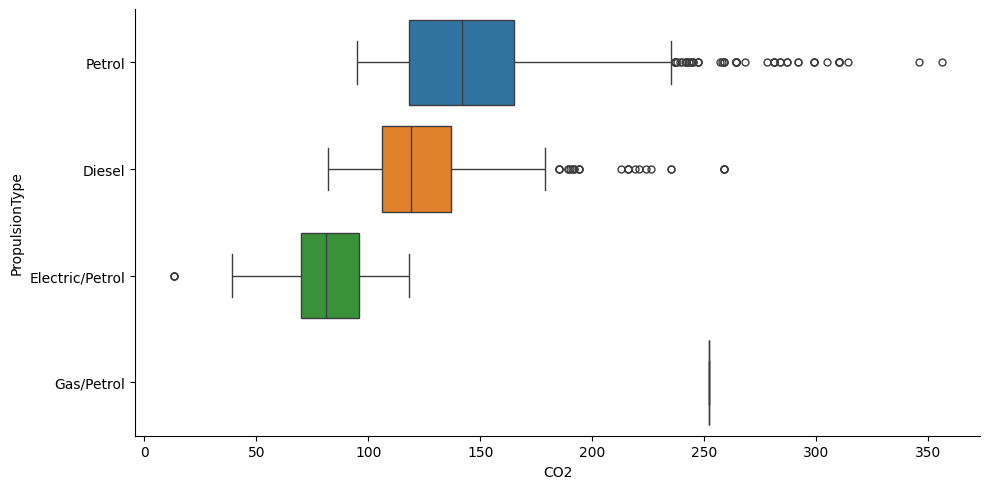

In [ ]:
# create box plots for CO2 grouped by PropulsionType
sns.catplot(data=cars_data2, kind='box', x='CO2', y='PropulsionType', hue='PropulsionType', aspect=2)

## Checkpoint 2
> Use the statistics and charts to answer the original problem:
>
> ***Are petrol or diesel cars heavier and which have higher emissions?***

# Exploring Petrol cars


In [ ]:
# a new datset called petrol_data is created by copying only the rows where the Propulsion Type is Petrol
petrol_data = cars_data2[cars_data2['PropulsionType'] == 'Petrol'].copy()

# display the data to check
petrol_data

,ReferenceNumber,Make,PropulsionTypeId,BodyTypeId,GovRegion,KeeperTitleId,EngineSize,YearRegistered,Mass,CO2,CO,NOX,part,hc,Random number,PropulsionType
0,440,VAUXHALL,1,96,London,1,1598,2002,1970,190,0.219,0.026,NaN,0.037,0.430217,Petrol
1,1465,VAUXHALL,1,14,South West,5,1398,2016,1163,118,0.463,0.010,NaN,0.031,0.797111,Petrol
2,3434,VOLKSWAGEN,1,14,South West,2,1395,2016,1316,113,0.242,0.033,NaN,0.048,0.348442,Petrol
3,1801,VAUXHALL,1,14,South West,4,1598,2016,1355,159,0.809,0.012,NaN,0.051,0.968447,Petrol
6,1323,VAUXHALL,1,14,South West,5,1398,2016,1163,118,0.463,0.010,NaN,0.031,0.526516,Petrol
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3819,1903,VOLKSWAGEN,1,13,London,1,1197,2016,1139,109,0.199,0.018,NaN,0.035,0.078803,Petrol
3820,2913,FORD,1,5,North West,1,4951,2016,1799,299,0.621,0.018,NaN,0.046,0.787504,Petrol
3821,706,FORD,1,13,North West,1,1299,2002,965,154,0.395,0.103,NaN,0.061,0.934800,Petrol
3824,3498,FORD,1,14,South West,1,999,2016,1333,108,0.447,0.030,0.002,0.076,0.736612,Petrol


## Pre-processing the data 2
You can further explore the mass and emissions of the cars in the data set by comparing the different makes within each of the petrol and diesel categories. To do this you will neeed to filter or *slice* the data to create subsets that only contain the petrol cars or only contain the diesel cars.

To filter the data you can create a new dataset that contains only the rows where a required condition holds. In the text below, this line

`petrol_data = cars_data2[cars_data2['PropulsionType'] == 'Petrol']`

creates a new data set called `petrol_data` that contains only the rows for which the propulsion type is "Petrol".

> Run the code below to create the new data set

## Exploring the data 2
You can now compare the masses of different makes of petrol cars by calculating statistics and creating box plots.

> Run the code in the boxes below to calculate the statistics and create box plots for mass.

In [ ]:
# display the statistics for Mass grouped by Make
petrol_data.groupby('Make')['Mass'].describe()

,count,mean,std,min,25%,50%,75%,max
Make,,,,,,,,
BMW,195.0,1550.743590,159.251101,1355.0,1427.5,1540.0,1615.00,2350.0
FORD,647.0,1251.185471,193.934629,965.0,1155.5,1177.0,1377.00,1810.0
TOYOTA,150.0,1220.520000,204.095803,925.0,1050.0,1260.0,1328.75,1800.0
VAUXHALL,806.0,1336.500000,222.951031,1034.0,1163.0,1278.0,1430.00,2200.0
VOLKSWAGEN,451.0,1227.833703,161.607539,929.0,1107.0,1229.0,1327.00,1899.0


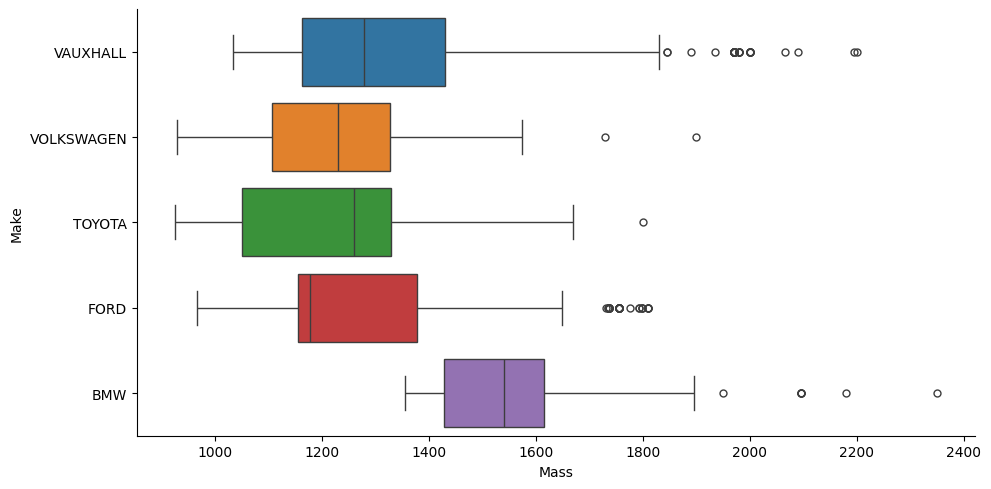

In [ ]:
# create box plots for Mass grouped by Make
sns.catplot(data=petrol_data, kind='box', x='Mass', y='Make', hue='Make', aspect=2);

> Copy and change the code in the boxes below to calculate the statistics and create box plots for the $CO_2$ emissions of petrol cars.

In [ ]:
# display the statistics for CO2 grouped by Make
petrol_data.groupby('Make')['CO2'].describe()

,count,mean,std,min,25%,50%,75%,max
Make,,,,,,,,
BMW,195.0,183.835897,51.388592,116.0,136.5,175.0,226.0,356.0
FORD,647.0,152.043277,36.995958,99.0,122.0,154.0,165.0,305.0
TOYOTA,150.0,158.780000,37.125376,95.0,137.0,159.0,185.0,259.0
VAUXHALL,806.0,139.044665,26.683942,100.0,118.0,128.0,154.0,284.0
VOLKSWAGEN,451.0,139.847007,31.231197,99.0,109.0,142.0,159.0,314.0


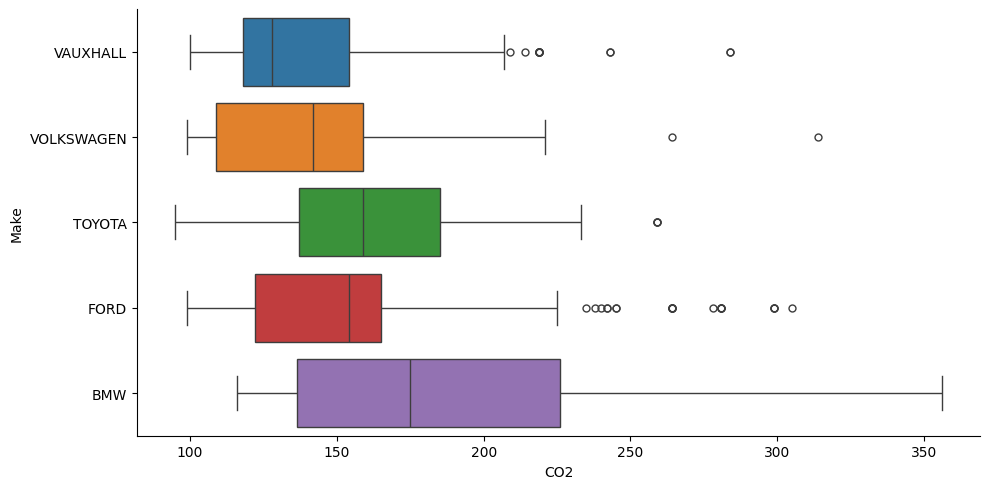

In [ ]:
# create box plots for CO2 grouped by Make
sns.catplot(data=petrol_data, x= 'CO2', y='Make', kind='box', hue='Make', aspect=2)

# Exploring Diesel cars

## Pre-processing the data 3

> Copy the code that created a slice of the petrol cars into the box below and change it so that it creates a slice for the diesel cars.

In [ ]:
# a new datset called diesel_data is created by copying only the rows where the Propulsion Type is Diesel
diesel_data = cars_data2[cars_data2['PropulsionType'] == 'Diesel'].copy()

# display the data to check
diesel_data

,ReferenceNumber,Make,PropulsionTypeId,BodyTypeId,GovRegion,KeeperTitleId,EngineSize,YearRegistered,Mass,CO2,CO,NOX,part,hc,Random number,PropulsionType
4,2330,BMW,2,13,South West,5,1995,2016,1445,114,0.180,0.023,NaN,NaN,0.178227,Diesel
5,2216,FORD,2,6,South West,5,1499,2016,1425,98,0.354,0.074,NaN,NaN,0.423774,Diesel
9,2971,VOLKSWAGEN,2,6,South West,5,2967,2016,2185,174,0.138,0.039,NaN,NaN,0.225134,Diesel
11,2707,FORD,2,14,North West,5,1499,2016,1399,98,0.354,0.074,NaN,NaN,0.853962,Diesel
12,2419,VAUXHALL,2,6,South West,5,1598,2016,1393,89,0.268,0.047,NaN,NaN,0.149359,Diesel
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3817,1118,TOYOTA,2,14,South West,1,1995,2002,1415,153,0.240,0.450,0.034,NaN,0.184194,Diesel
3818,326,TOYOTA,2,6,South West,1,1995,2002,1560,190,0.080,0.440,0.036,NaN,0.139254,Diesel
3822,2920,FORD,2,14,North West,5,1997,2016,1681,122,0.145,0.059,0.001,NaN,0.946550,Diesel
3823,1800,FORD,2,96,London,2,1997,2016,1833,134,0.305,0.054,NaN,NaN,0.538774,Diesel


## Exploring the data 3

> Copy the code for the statistics and charts of petrol cars grouped by make into the box below and change it to display these for diesel cars.

In [ ]:
# display the statistics for Mass of diesel cars grouped by Make
diesel_data.groupby('Make')['Mass'].describe()

,count,mean,std,min,25%,50%,75%,max
Make,,,,,,,,
BMW,309.0,1642.621359,218.592210,1395.0,1470.00,1605.0,1760.00,2265.0
FORD,423.0,1547.049645,212.018140,1116.0,1399.00,1564.0,1681.00,2030.0
TOYOTA,13.0,1557.230769,321.560817,1100.0,1490.00,1505.0,1610.00,2395.0
VAUXHALL,262.0,1550.229008,244.726936,1199.0,1350.00,1495.5,1701.00,2450.0
VOLKSWAGEN,358.0,1494.081006,175.325952,1056.0,1388.75,1475.0,1567.25,2185.0


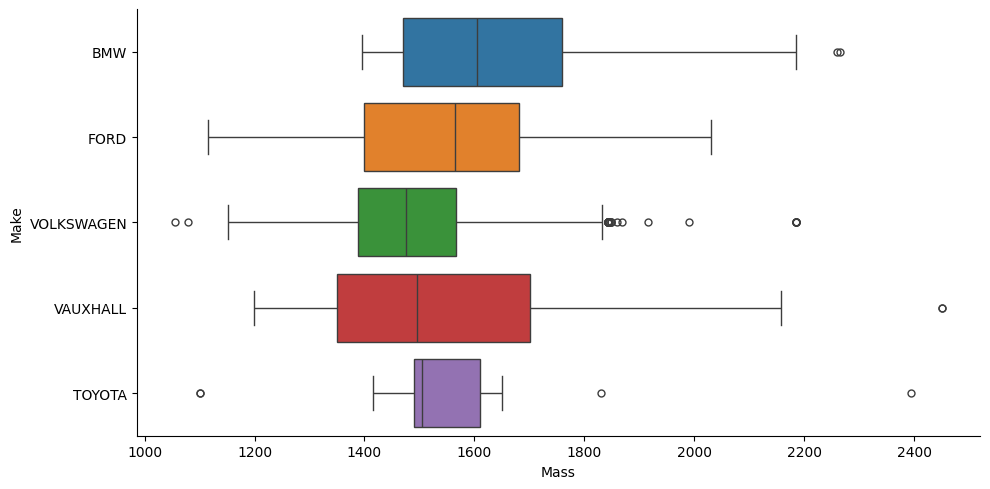

In [ ]:
# create box plots for Mass of diesel cars grouped by Make
sns.catplot(data=diesel_data, kind='box', x='Mass', y='Make', hue='Make', aspect=2)

In [ ]:
# display the statistics for CO2 of diesel cars grouped by Make
diesel_data.groupby('Make')['CO2'].describe()

,count,mean,std,min,25%,50%,75%,max
Make,,,,,,,,
BMW,309.0,127.291262,29.821971,89.0,109.0,118.0,139.00,259.0
FORD,423.0,119.186761,19.050460,82.0,105.0,119.0,129.50,173.0
TOYOTA,13.0,150.000000,31.717503,109.0,117.0,158.0,164.00,194.0
VAUXHALL,262.0,115.904580,25.843666,84.0,99.0,109.0,129.75,235.0
VOLKSWAGEN,358.0,129.067039,22.135462,88.0,110.0,127.0,146.00,224.0


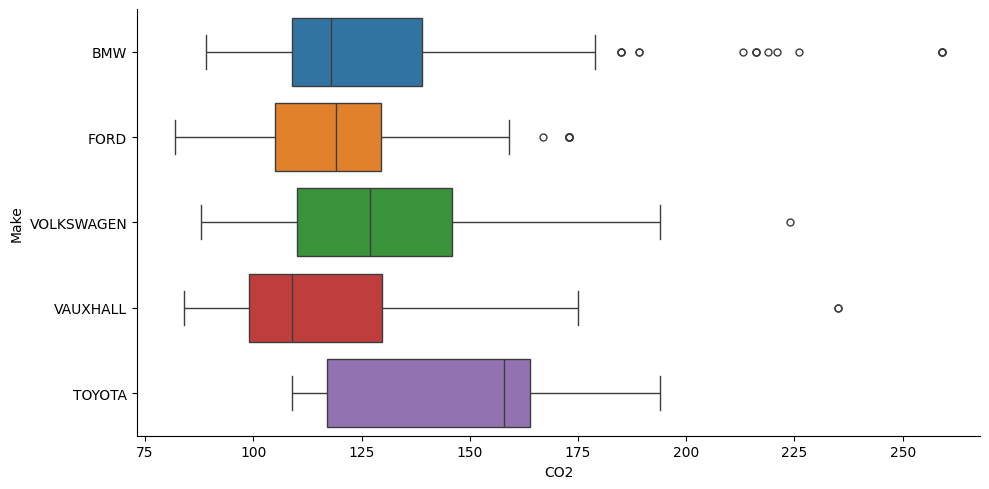

In [ ]:
# create box plots for CO2 of diesel cars grouped by Make
sns.catplot(data=diesel_data, kind='box', x='CO2', y='Make', hue='Make', aspect=2)

# Communicating the results

## Checkpoint 3
> Use the statstics and charts to answer the original problem:
>
> ***Are petrol or diesel cars heavier and which have higher emissions? Are there differences for cars of different makes?***